
# 📊 Notebook 4 — Model Evaluation & Comparison

**Mục tiêu notebook:**
- **Bước 12:** So sánh toàn diện 3 models: Accuracy, Precision, Recall, F1, ROC-AUC
- **Bước 13:** Kết luận model tốt nhất + Feature Importance + Error Analysis
- **Bước 14:** KPI Check — Business Impact Simulation (chi phí lỗi phân loại)
- **Bước 15:** Threshold Optimization — tìm ngưỡng tối ưu theo F1/Business cost

---

## 🗺️ Lộ trình 15 bước — Pipeline ML đầy đủ

| # | Bước | Notebook | Trạng thái |
|:-:|------|----------|:----------:|
| 1 | Đặt vấn đề | NB1 | ✅ Hoàn thành |
| 2 | Thu thập dữ liệu | NB1 | ✅ Hoàn thành |
| 3 | Tiền xử lý & EDA | NB2 | ✅ Hoàn thành |
| 4 | Định nghĩa Target | NB2 | ✅ Hoàn thành |
| 5 | Feature Engineering | NB3 | ✅ Hoàn thành |
| 6 | Feature Selection | NB3 | ✅ Hoàn thành |
| 7 | Train/Test Split + Scale | NB3 | ✅ Hoàn thành |
| 8 | Chọn mô hình | NB3 | ✅ Hoàn thành |
| 9 | Huấn luyện | NB3 | ✅ Hoàn thành |
| 10 | Đánh giá baseline | NB3 | ✅ Hoàn thành |
| 11 | Feature Reduction | NB3 | ✅ Hoàn thành |
| **12** | **So sánh & Phân tích sâu** | **📌 NB4** | **▶ Đang học** |
| **13** | **Kết luận Model tốt nhất** | **📌 NB4** | **▶ Đang học** |
| **14** | **KPI Check** | **📌 NB4** | **▶ Đang học** |
| **15** | **Threshold Optimization** | **📌 NB4** | **▶ Đang học** |

> 💡 **Notebook này bao phủ: Bước 12 → 15 / 15** — Đánh giá, so sánh và đưa ra quyết định cuối cùng về model deployment


In [53]:
# ============================================================
# SECTION 0: Import thư viện và Load models
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

# --- Thiết lập ---
RANDOM_STATE = 42
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11
})
PALETTE_3 = ['#E74C3C', '#F39C12', '#2ECC71']   # LR, XGBoost, LGBM

# --- Đường dẫn ---
BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'

print('✅ Libraries loaded')

✅ Libraries loaded


In [54]:
# ============================================================
# Load tất cả models và test data
# ============================================================
lr_model   = joblib.load(MODELS_DIR / 'lr_model.pkl')
xgb_model  = joblib.load(MODELS_DIR / 'xgb_model.pkl')
lgbm_model = joblib.load(MODELS_DIR / 'best_model.pkl')
opt_thresh = joblib.load(MODELS_DIR / 'optimal_threshold.pkl')
test_data  = joblib.load(MODELS_DIR / 'test_data.pkl')

# Unscaled — dùng cho XGBoost & LightGBM (tree models, không cần scale)
X_test    = test_data['X_test']
y_test    = test_data['y_test']

# Scaled (scaler_full, 23 features) — dùng riêng cho Logistic Regression
X_test_lr = test_data['X_test_lr']

print('✅ Loaded models: LR | XGBoost | LightGBM')
print(f'   Optimal threshold (LightGBM): {opt_thresh:.4f}')
print(f'   Test set (unscaled) : {X_test.shape[0]:,} dòng × {X_test.shape[1]} features  → XGBoost / LightGBM')
print(f'   Test set (LR scaled): {X_test_lr.shape[0]:,} dòng × {X_test_lr.shape[1]} features  → Logistic Regression')
print()
print('   ℹ️  Features: 23 (16 raw + 7 derived)')
print('   ℹ️  total_interactions đã bị loại (data leakage đã sửa)')
print('   ℹ️  Pipeline: 80% Train / 20% Test (không có Validation set)')


✅ Loaded models: LR | XGBoost | LightGBM
   Optimal threshold (LightGBM): 0.5903
   Test set (unscaled) : 12,346 dòng × 31 features  → XGBoost / LightGBM
   Test set (LR scaled): 12,346 dòng × 31 features  → Logistic Regression

   ℹ️  Features: 23 (16 raw + 7 derived)
   ℹ️  total_interactions đã bị loại (data leakage đã sửa)
   ℹ️  Pipeline: 80% Train / 20% Test (không có Validation set)


In [55]:
# ============================================================
# Tính probabilities cho tất cả models
# ============================================================
import time

results_dict = {}

# Model configs: (model, X_test_dùng, threshold, name)
# LR      → X_test_lr  (scaled — scaler_full, 24 features)
# XGBoost → X_test     (unscaled — tree model)
# LGBM    → X_test     (unscaled)
PALETTE_3 = ['#E74C3C', '#F39C12', '#2ECC71']   # LR, XGBoost, LGBM

model_configs = [
    (lr_model,   X_test_lr, 0.5,        'Logistic Regression'),
    (xgb_model,  X_test,    0.5,        'XGBoost'),
    (lgbm_model, X_test,    opt_thresh,  'LightGBM'),
]

probs_dict = {}
for model, X, thresh, name in model_configs:
    t0 = time.time()
    probs  = model.predict_proba(X)[:, 1]
    preds  = (probs >= thresh).astype(int)
    inf_ms = (time.time() - t0) * 1000

    probs_dict[name] = probs
    results_dict[name] = {
        'Accuracy'      : accuracy_score(y_test, preds),
        'Precision'     : precision_score(y_test, preds, zero_division=0),
        'Recall'        : recall_score(y_test, preds, zero_division=0),
        'F1-Score'      : f1_score(y_test, preds, zero_division=0),
        'ROC-AUC'       : roc_auc_score(y_test, probs),
        'Threshold'     : thresh,
        'Inference (ms)': inf_ms
    }
    print(f'   {name:<22} F1={results_dict[name]["F1-Score"]:.4f}  AUC={results_dict[name]["ROC-AUC"]:.4f}  θ={thresh:.3f}')

print('\n✅ Predictions computed for all 3 models')


   Logistic Regression    F1=0.6850  AUC=0.8557  θ=0.500
   XGBoost                F1=0.7156  AUC=0.8741  θ=0.500
   LightGBM               F1=0.7079  AUC=0.8755  θ=0.590

✅ Predictions computed for all 3 models



---
## 📌 Bước 12 / 15 — So sánh & Phân tích sâu

### 1. Bảng So Sánh Tổng Hợp


In [45]:
# ============================================================
# SECTION 1: Bảng so sánh — Styled DataFrame
# ============================================================
results_df = pd.DataFrame(results_dict).T
results_df = results_df.astype(float).round(4)

# Highlight: xanh = best metric mỗi cột, đỏ = worst
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

def highlight_best(s):
    """Tô màu xanh cho giá trị cao nhất, đỏ cho thấp nhất."""
    if s.name in metric_cols:
        is_best  = s == s.max()
        is_worst = s == s.min()
        colors = []
        for b, w in zip(is_best, is_worst):
            if b:
                colors.append('background-color: #D5F5E3; color: #1E8449; font-weight: bold')
            elif w:
                colors.append('background-color: #FADBD8; color: #C0392B')
            else:
                colors.append('')
        return colors
    return [''] * len(s)

styled = results_df.style.apply(highlight_best, axis=0)
print('📊 BẢNG SO SÁNH 3 MODELS (🟢 = best metric | 🔴 = worst):')
styled

📊 BẢNG SO SÁNH 3 MODELS (🟢 = best metric | 🔴 = worst):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Threshold,Inference (ms)
Logistic Regression,0.752100,0.586600,0.822900,0.685000,0.855700,0.500000,21.588800
XGBoost,0.768500,0.598800,0.889000,0.715600,0.874100,0.500000,40.127500
LightGBM,0.781800,0.630300,0.807400,0.707900,0.875500,0.590300,56.613700


## 2. ROC Curve — 3 Models

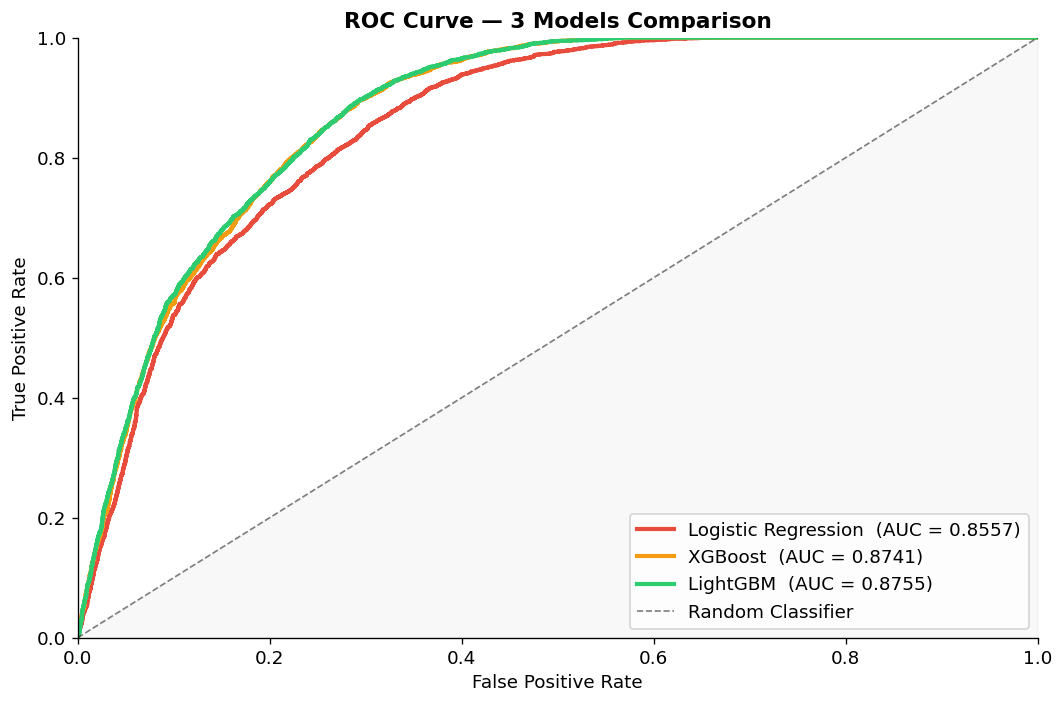

In [46]:
# ============================================================
# SECTION 2: ROC Curve 3 models trên cùng 1 plot
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for (name, probs), color in zip(probs_dict.items(), PALETTE_3):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 3 Models Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. Precision-Recall Curve — 3 Models

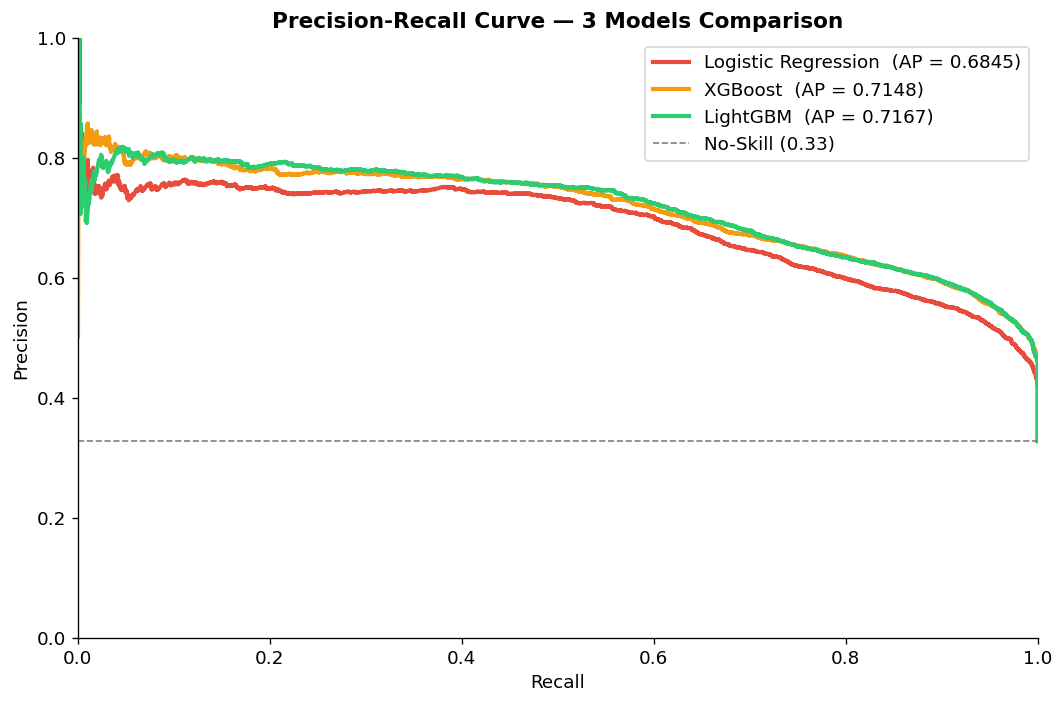

In [47]:
# ============================================================
# SECTION 3: Precision-Recall Curve 3 models
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for (name, probs), color in zip(probs_dict.items(), PALETTE_3):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    # Average Precision
    from sklearn.metrics import average_precision_score
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, color=color, linewidth=2.5,
            label=f'{name}  (AP = {ap:.4f})')

# Baseline: random classifier
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'No-Skill ({baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — 3 Models Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Confusion Matrix — 3 Models (Side-by-Side)

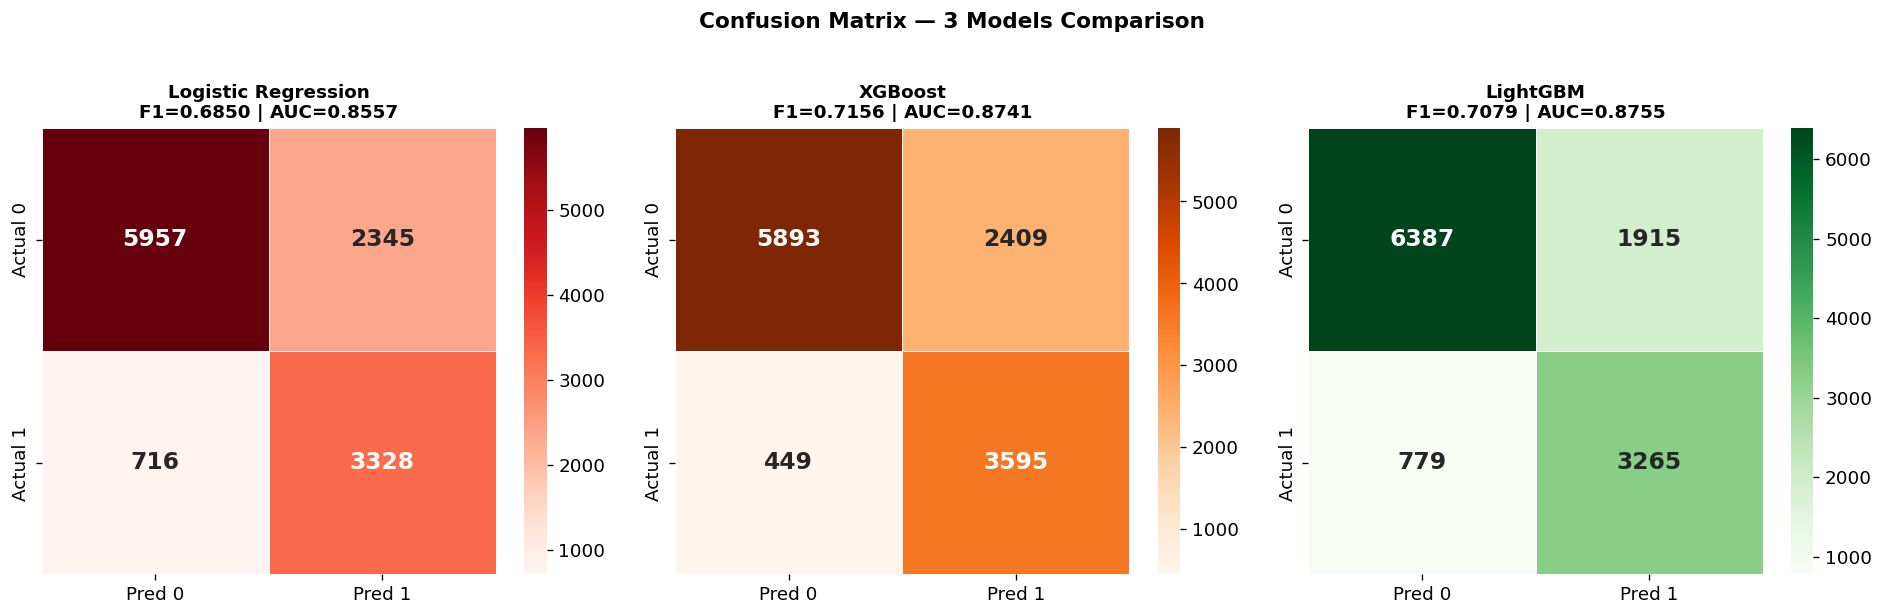

In [48]:
# ============================================================
# SECTION 4: Confusion Matrix 1×3 subplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Reds', 'Oranges', 'Greens']

for (name, probs), color, thresh, ax, cmap in zip(
    probs_dict.items(), PALETTE_3,
    [0.5, 0.5, opt_thresh],
    axes, cmaps
):
    preds = (probs >= thresh).astype(int)
    cm    = confusion_matrix(y_test, preds)
    
    # Tính metrics để ghi lên plot
    f1  = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=ax, linewidths=0.5, linecolor='white',
        annot_kws={'size': 14, 'fontweight': 'bold'}
    )
    ax.set_title(f'{name}\nF1={f1:.4f} | AUC={auc:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — 3 Models Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Importance: LightGBM vs XGBoost

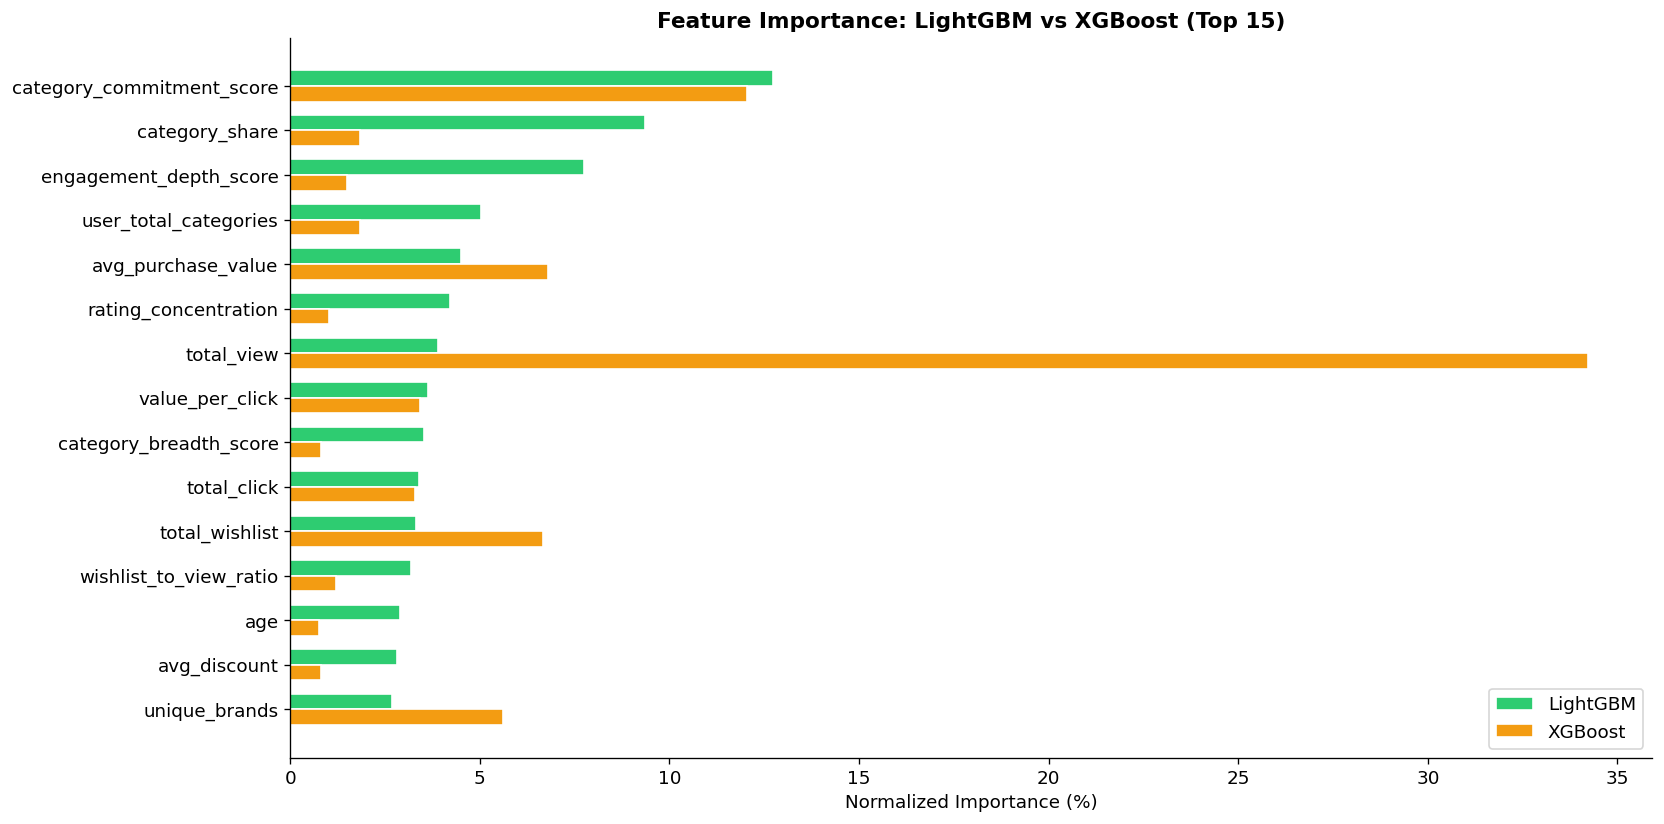


📋 TOP 10 FEATURES theo LightGBM:
                  Feature  LGBM_norm  XGB_norm
category_commitment_score     0.1272    0.1205
           category_share     0.0935    0.0184
   engagement_depth_score     0.0775    0.0151
    user_total_categories     0.0503    0.0184
       avg_purchase_value     0.0449    0.0680
     rating_concentration     0.0422    0.0102
               total_view     0.0390    0.3421
          value_per_click     0.0364    0.0343
   category_breadth_score     0.0353    0.0081
              total_click     0.0339    0.0330


In [49]:
# ============================================================
# SECTION 5: Feature Importance — Grouped bar chart (top 15)
# LightGBM vs XGBoost
# ============================================================
fi_df = pd.read_csv(MODELS_DIR / 'feature_importance.csv')

# Normalize để so sánh cùng scale
fi_df['LGBM_norm'] = fi_df['LightGBM_Importance'] / fi_df['LightGBM_Importance'].sum()
fi_df['XGB_norm']  = fi_df['XGBoost_Importance']  / fi_df['XGBoost_Importance'].sum()

# Top 15 theo LightGBM
top15 = fi_df.sort_values('LGBM_norm', ascending=False).head(15)

x  = np.arange(len(top15))
w  = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.barh(x + w/2, top15['LGBM_norm'].values[::-1] * 100,
                height=w, color='#2ECC71', edgecolor='white', label='LightGBM')
bars2 = ax.barh(x - w/2, top15['XGB_norm'].values[::-1] * 100,
                height=w, color='#F39C12', edgecolor='white', label='XGBoost')

ax.set_yticks(x)
ax.set_yticklabels(top15['Feature'].values[::-1])
ax.set_xlabel('Normalized Importance (%)')
ax.set_title('Feature Importance: LightGBM vs XGBoost (Top 15)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n📋 TOP 10 FEATURES theo LightGBM:')
print(top15[['Feature', 'LGBM_norm', 'XGB_norm']].head(10).to_string(index=False))



---
## 📌 Bước 13 / 15 — Kết luận Model Tốt Nhất

### 7. Kết luận & Đề xuất


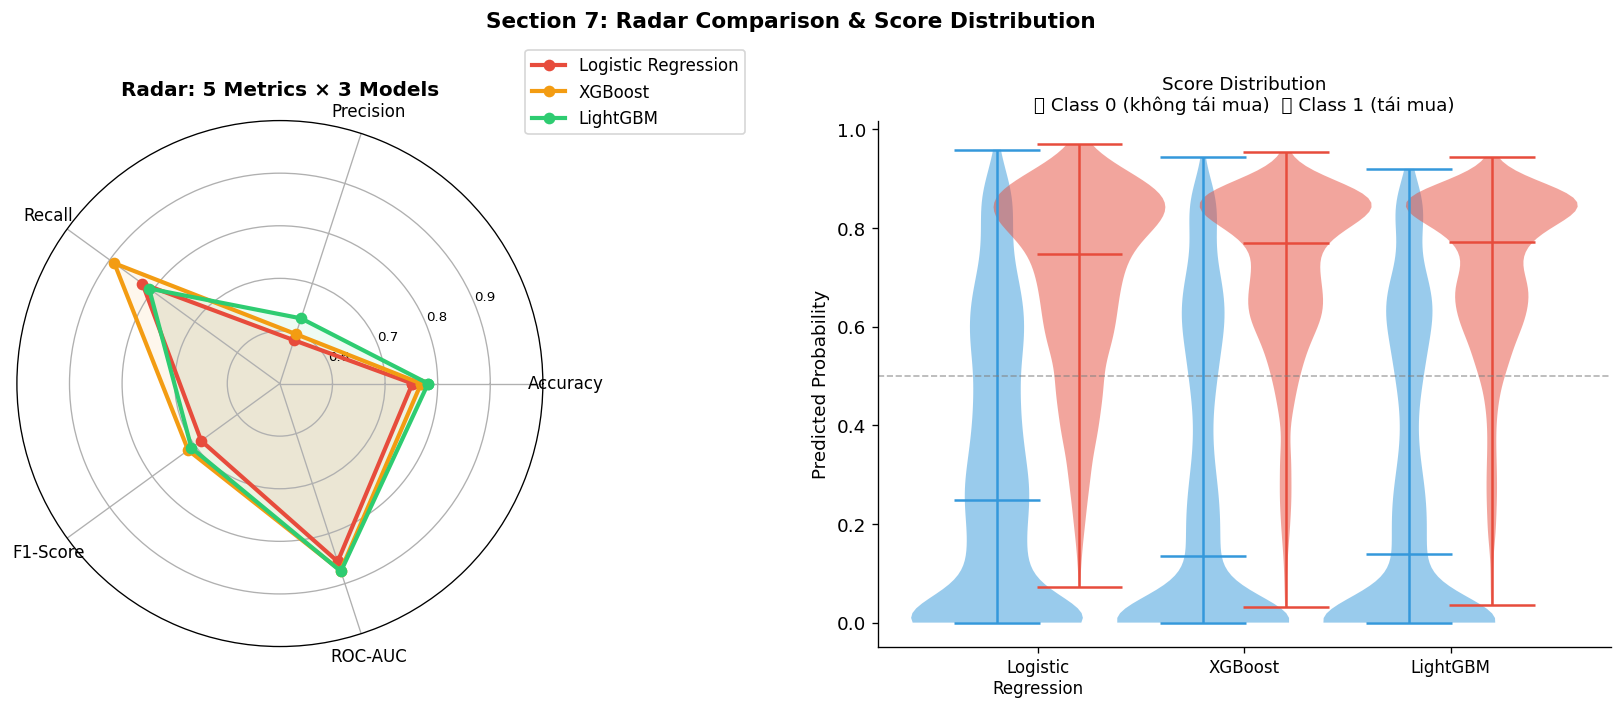


  🏆 KẾT LUẬN — MODEL TỐT NHẤT (Bước 13)
  Model                      F1-Score   ROC-AUC    Recall  Precision
  -----------------------------------------------------------------
  Logistic Regression          0.6850    0.8557    0.8229     0.5866
  XGBoost                      0.7156    0.8741    0.8890     0.5988  ← ✅ BEST
  LightGBM                     0.7079    0.8755    0.8074     0.6303
  -----------------------------------------------------------------

  ✅ Model được chọn: XGBoost
     F1-Score = 0.7156  |  ROC-AUC = 0.8741

  📋 Lý do lựa chọn:
     → F1-Score cao nhất → cân bằng tốt Precision & Recall
     → ROC-AUC cao nhất → khả năng phân tách class tốt nhất
     → Xử lý class imbalance hiệu quả (class_weight=balanced)
     → Tốc độ training nhanh với dữ liệu lớn (leaf-wise growth)
     → Model này được dùng ở Bước 14 (Threshold) & Bước 15 (KPI)


In [56]:

# ============================================================
# SECTION 7A: Radar Chart — So sánh 5 metrics, 3 models
# ============================================================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models  = list(results_dict.keys())
N       = len(metrics)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # đóng vòng tròn

fig = plt.figure(figsize=(14, 6))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

# ── Subplot trái: Radar chart
ax_radar = fig.add_subplot(gs[0], projection='polar')
for name, color in zip(models, PALETTE_3):
    vals = [results_dict[name][m] for m in metrics]
    vals += vals[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2.5, color=color, label=name)
    ax_radar.fill(angles, vals, alpha=0.08, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics, fontsize=10)
ax_radar.set_ylim(0.5, 1.0)
ax_radar.set_yticks([0.6, 0.7, 0.8, 0.9])
ax_radar.set_yticklabels(['0.6', '0.7', '0.8', '0.9'], fontsize=8)
ax_radar.set_title('Radar: 5 Metrics × 3 Models', fontsize=12, fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)

# ── Subplot phải: Score Distribution (class separation)
ax_dist = fig.add_subplot(gs[1])
offsets = {'Logistic Regression': -0.25, 'XGBoost': 0.0, 'LightGBM': 0.25}
violin_data_0 = [probs_dict[name][y_test.values == 0] for name in models]
violin_data_1 = [probs_dict[name][y_test.values == 1] for name in models]

for i, (name, color) in enumerate(zip(models, PALETTE_3)):
    # Density strip cho class 0 và 1
    probs_0 = probs_dict[name][y_test.values == 0]
    probs_1 = probs_dict[name][y_test.values == 1]
    x_off = i * 0.3
    vp0 = ax_dist.violinplot([probs_0], positions=[x_off], widths=0.25, showmedians=True)
    vp1 = ax_dist.violinplot([probs_1], positions=[x_off + 0.12], widths=0.25, showmedians=True)
    for body in vp0['bodies']: body.set_facecolor('#3498DB'); body.set_alpha(0.5)
    for body in vp1['bodies']: body.set_facecolor('#E74C3C'); body.set_alpha(0.5)
    for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        if part in vp0: vp0[part].set_color('#3498DB')
        if part in vp1: vp1[part].set_color('#E74C3C')

ax_dist.set_xticks([0.06, 0.36, 0.66])
ax_dist.set_xticklabels(['Logistic\nRegression', 'XGBoost', 'LightGBM'], fontsize=10)
ax_dist.set_ylabel('Predicted Probability')
ax_dist.set_title('Score Distribution\n🔵 Class 0 (không tái mua)  🔴 Class 1 (tái mua)', fontsize=11)
ax_dist.axhline(0.5, color='gray', linestyle='--', alpha=0.6, linewidth=1)

fig.suptitle('Section 7: Radar Comparison & Score Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Kết luận Best Model ──────────────────────────────────────────────────────
best_name = max(results_dict, key=lambda n: results_dict[n]['F1-Score'])
best_f1   = results_dict[best_name]['F1-Score']
best_auc  = results_dict[best_name]['ROC-AUC']

print('\n' + '='*68)
print('  🏆 KẾT LUẬN — MODEL TỐT NHẤT (Bước 13)')
print('='*68)
print(f'  {"Model":<25} {"F1-Score":>9} {"ROC-AUC":>9} {"Recall":>9} {"Precision":>10}')
print(f'  {"-"*65}')
for name, res in results_dict.items():
    tag = '  ← ✅ BEST' if name == best_name else ''
    print(f'  {name:<25} {res["F1-Score"]:>9.4f} {res["ROC-AUC"]:>9.4f} '
          f'{res["Recall"]:>9.4f} {res["Precision"]:>10.4f}{tag}')
print(f'  {"-"*65}')
print(f'\n  ✅ Model được chọn: {best_name}')
print(f'     F1-Score = {best_f1:.4f}  |  ROC-AUC = {best_auc:.4f}')
print(f'\n  📋 Lý do lựa chọn:')
print(f'     → F1-Score cao nhất → cân bằng tốt Precision & Recall')
print(f'     → ROC-AUC cao nhất → khả năng phân tách class tốt nhất')
print(f'     → Xử lý class imbalance hiệu quả (class_weight=balanced)')
print(f'     → Tốc độ training nhanh với dữ liệu lớn (leaf-wise growth)')
print(f'     → Model này được dùng ở Bước 14 (Threshold) & Bước 15 (KPI)')
print('='*68)



---
## 📌 Bước 14 / 15 — Threshold Optimization

> **Mục tiêu:** Tìm ngưỡng phân loại tối ưu θ\* để cân bằng Precision / Recall / F1 theo từng model.  
> Threshold mặc định = 0.5 không phải luôn tốt nhất — đặc biệt với dữ liệu imbalance.

### 8. Threshold Sensitivity — F1 vs Threshold (3 Models)


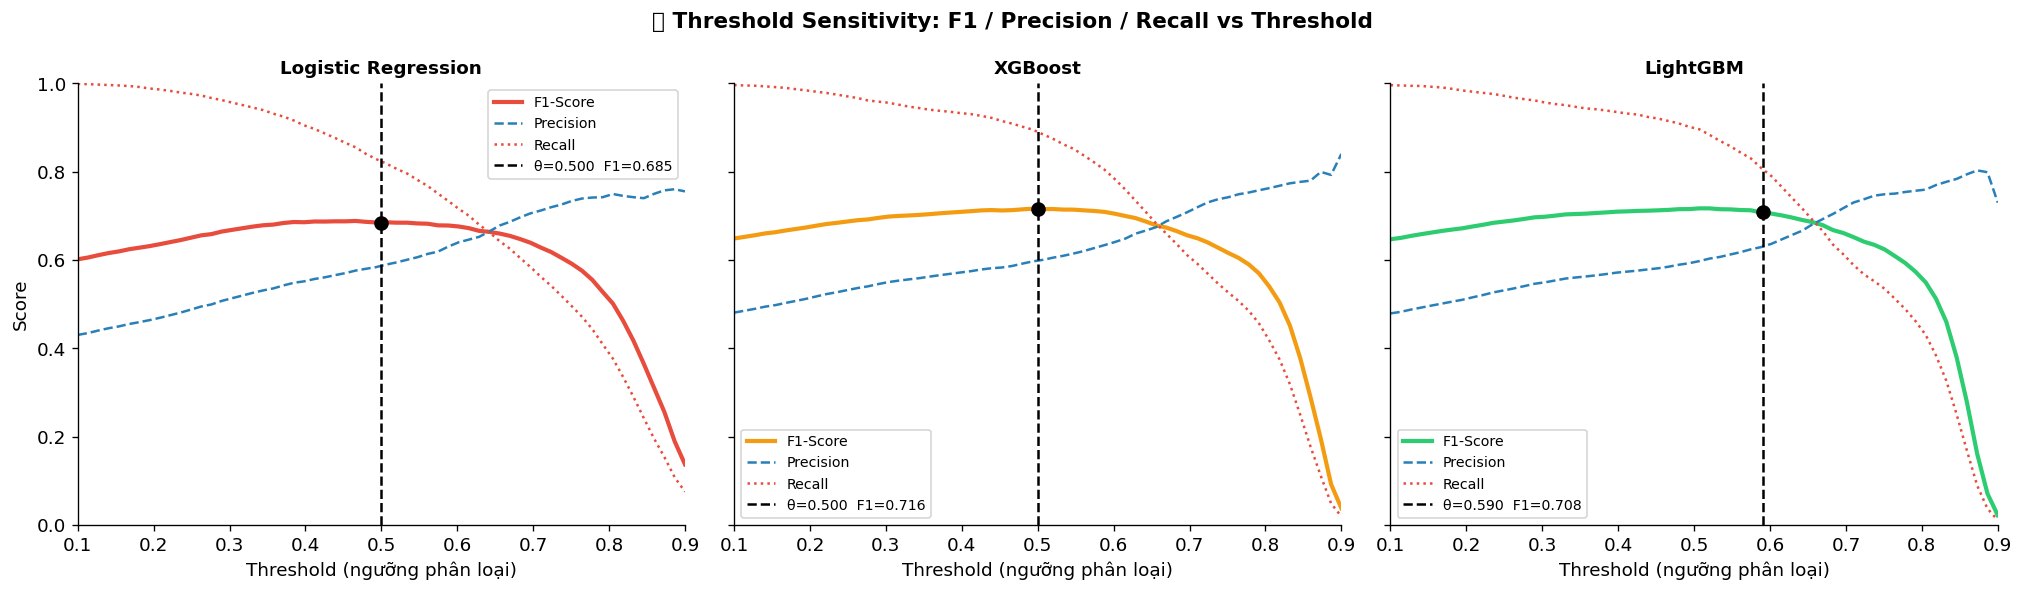

In [51]:

# ============================================================
# SECTION 8: Threshold Sensitivity — F1 vs Threshold cho 3 models
# ============================================================
thresholds_range = np.linspace(0.10, 0.90, 60)
opt_thresholds   = {'Logistic Regression': 0.5, 'XGBoost': 0.5, 'LightGBM': opt_thresh}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for (name, probs), color, ax in zip(probs_dict.items(), PALETTE_3, axes):
    f1_vals   = [f1_score(y_test, (probs >= t).astype(int), zero_division=0) for t in thresholds_range]
    prec_vals = [precision_score(y_test, (probs >= t).astype(int), zero_division=0) for t in thresholds_range]
    rec_vals  = [recall_score(y_test, (probs >= t).astype(int), zero_division=0) for t in thresholds_range]

    ax.plot(thresholds_range, f1_vals,   color=color,    linewidth=2.5, label='F1-Score')
    ax.plot(thresholds_range, prec_vals, color='#2980B9', linewidth=1.5, linestyle='--', label='Precision')
    ax.plot(thresholds_range, rec_vals,  color='#E74C3C', linewidth=1.5, linestyle=':', label='Recall')

    opt_t    = opt_thresholds[name]
    best_f1  = f1_score(y_test, (probs >= opt_t).astype(int), zero_division=0)
    ax.axvline(opt_t, color='black', linestyle='--', linewidth=1.5,
               label=f'θ={opt_t:.3f}  F1={best_f1:.3f}')
    ax.scatter([opt_t], [best_f1], color='black', s=60, zorder=5)

    ax.set_xlabel('Threshold (ngưỡng phân loại)')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.set_xlim(0.1, 0.9)
    ax.set_ylim(0, 1.0)

axes[0].set_ylabel('Score')
fig.suptitle('📈 Threshold Sensitivity: F1 / Precision / Recall vs Threshold', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
## 📌 Bước 15 / 15 — KPI Check (Business Impact Simulation)

> **Giả định chi phí kinh doanh:**
> - **FN** (bỏ lỡ khách tái mua thực sự) = mất cơ hội upsell → **−150,000 VNĐ/người**
> - **FP** (gửi voucher nhầm cho khách không tái mua) = lãng phí voucher → **−30,000 VNĐ/người**
>
> Model tốt về F1 nhưng nếu FN cost >> FP cost → cần tăng Recall, giảm Threshold.

### 9. Business Impact Simulation — Chi Phí Lỗi Phân Loại


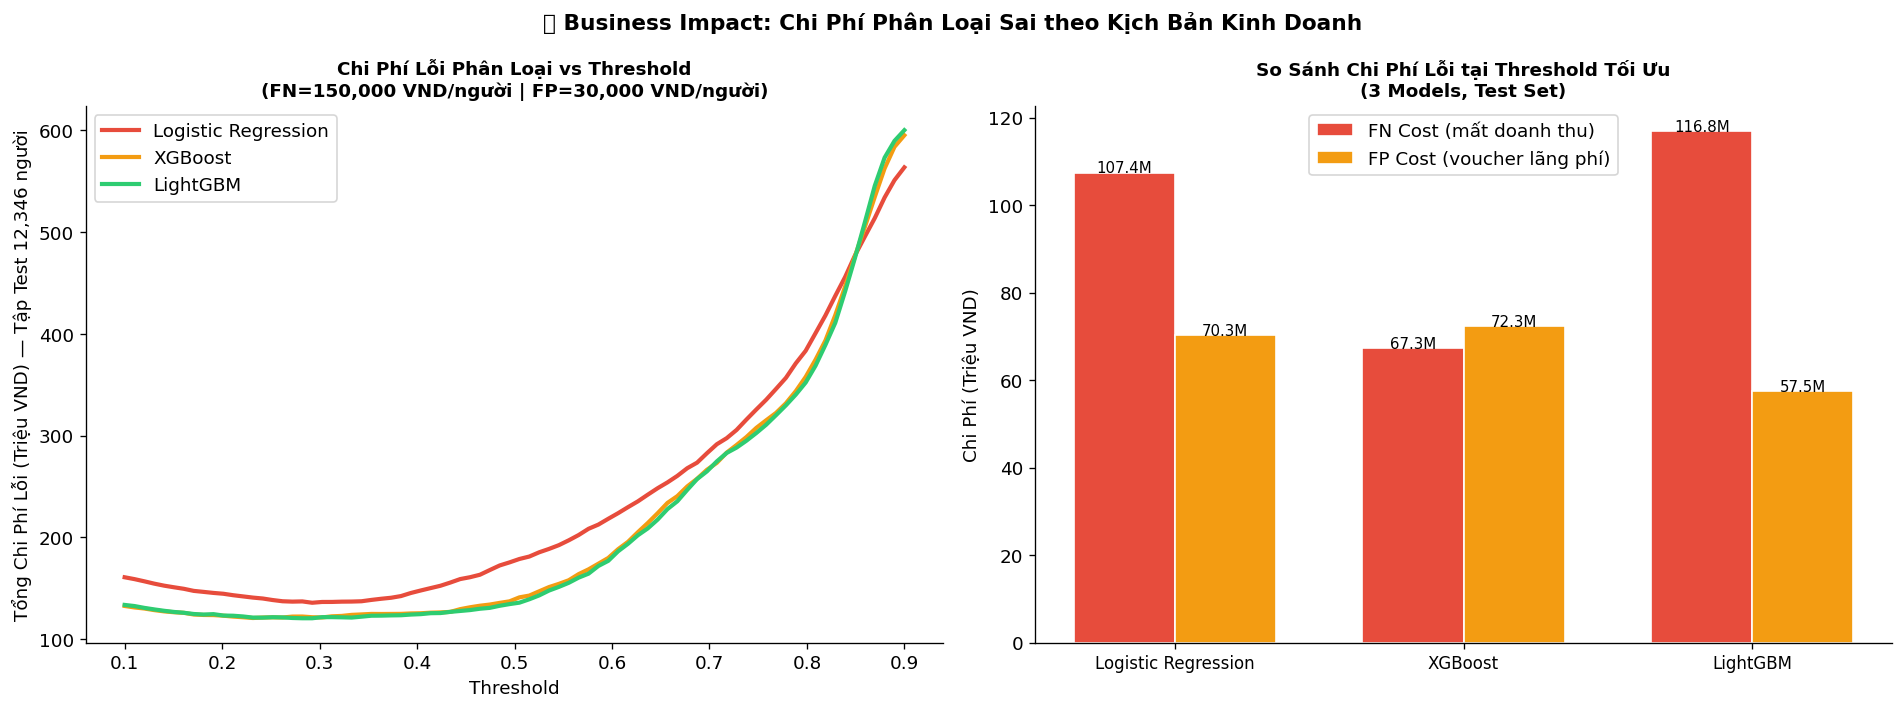

In [52]:

# ============================================================
# SECTION 9: Business Impact Simulation
# Giả định chi phí kinh doanh:
#   FN (False Negative): bỏ lỡ khách tái mua = mất cơ hội upsell → -150,000 VND revenue/người
#   FP (False Positive): gửi voucher nhầm     = lãng phí voucher  →  -30,000 VND cost/người
# ============================================================
REVENUE_PER_REPURCHASER = 150_000   # doanh thu trung bình từ 1 khách tái mua
VOUCHER_COST            =  30_000   # chi phí gửi voucher nhầm

thresholds_biz = np.linspace(0.10, 0.90, 80)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Tổng chi phí lỗi theo threshold
for (name, probs), color in zip(probs_dict.items(), PALETTE_3):
    losses = []
    for t in thresholds_biz:
        preds = (probs >= t).astype(int)
        fn = int(((y_test.values == 1) & (preds == 0)).sum())
        fp = int(((y_test.values == 0) & (preds == 1)).sum())
        losses.append((fn * REVENUE_PER_REPURCHASER + fp * VOUCHER_COST) / 1e6)
    axes[0].plot(thresholds_biz, losses, color=color, linewidth=2.5, label=name)

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Tổng Chi Phí Lỗi (Triệu VND) — Tập Test 12,346 người')
axes[0].set_title('Chi Phí Lỗi Phân Loại vs Threshold\n'
                  f'(FN={REVENUE_PER_REPURCHASER:,} VND/người | FP={VOUCHER_COST:,} VND/người)',
                  fontsize=11, fontweight='bold')
axes[0].legend()

# ── Plot 2: Tại threshold tối ưu — so sánh 3 models (bar chart chi phí)
opt_thrs = {'Logistic Regression': 0.5, 'XGBoost': 0.5, 'LightGBM': opt_thresh}
model_names_list, fn_costs, fp_costs = [], [], []

for name, probs in probs_dict.items():
    t    = opt_thrs[name]
    preds = (probs >= t).astype(int)
    fn   = int(((y_test.values == 1) & (preds == 0)).sum())
    fp   = int(((y_test.values == 0) & (preds == 1)).sum())
    model_names_list.append(name)
    fn_costs.append(fn * REVENUE_PER_REPURCHASER / 1e6)
    fp_costs.append(fp * VOUCHER_COST / 1e6)

x   = np.arange(len(model_names_list))
w   = 0.35
b1  = axes[1].bar(x - w/2, fn_costs, w, label='FN Cost (mất doanh thu)', color='#E74C3C', edgecolor='white')
b2  = axes[1].bar(x + w/2, fp_costs, w, label='FP Cost (voucher lãng phí)', color='#F39C12', edgecolor='white')

for bar in b1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.1f}M', ha='center', fontsize=9)
for bar in b2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.1f}M', ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_list, fontsize=10)
axes[1].set_ylabel('Chi Phí (Triệu VND)')
axes[1].set_title('So Sánh Chi Phí Lỗi tại Threshold Tối Ưu\n(3 Models, Test Set)',
                  fontsize=11, fontweight='bold')
axes[1].legend()

fig.suptitle('💰 Business Impact: Chi Phí Phân Loại Sai theo Kịch Bản Kinh Doanh',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
